# 04 - MultiTask Emotion2Vec CoAttention 10-Fold

Notebook này là notebook **model training** theo roadmap, mục `11.4 MultiTask_Emotion2Vec_CoAttention_10Fold`.

Setting hiện tại:

- Dataset local: `AbstractTTS/IEMOCAP` đã tải ở folder `06_w2v_based_models/datasets/AbstractTTS_IEMOCAP`.
- Label setting: `HF-major-emotion 4-class + AVD`, **N = 6,877**.
- Protocol: `10fold_speaker`.
- Split file: `iemocap_10fold_speaker_long.csv`.

Mục tiêu:

1. Load split đã tạo từ notebook 01.
2. Train multi-task model trên từng fold.
3. Emotion head dự đoán `neutral / angry / sad / happy`.
4. Regression head dự đoán `valence / arousal / dominance`.
5. Báo cáo WA, UAR, Macro-F1, Weighted-F1, CCC, MAE, RMSE.

Ghi chú quan trọng: notebook 02 hiện chưa có full emotion2vec embedding cache. Vì vậy notebook này mặc định chạy **M0 runnable baseline** bằng acoustic metadata features để kiểm pipeline model. Kiến trúc `Emotion2VecGuidedCrossAttentionModel` đã được đặt sẵn trong notebook để bật sau khi có cache emotion2vec thật.

In [1]:
from pathlib import Path
import json
import math
import os
import random
import time
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
)
from sklearn.preprocessing import StandardScaler

try:
    from IPython.display import display, Markdown
except Exception:
    display = print
    Markdown = lambda x: x

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 160)
pd.set_option("display.max_colwidth", 160)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)

DEVICE: cuda


In [2]:
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name != "Speech Project" and PROJECT_ROOT.parent.name == "Speech Project":
    PROJECT_ROOT = PROJECT_ROOT.parent.resolve()

BASE_DIR = PROJECT_ROOT / "06_w2v_based_models"
if not BASE_DIR.exists() and Path("/kaggle/working").exists():
    BASE_DIR = Path("/kaggle/working") / "06_w2v_based_models"

NOTEBOOK_DIR = BASE_DIR / "04MultiTask Emotion2Vec CoAttention 10Fold"

LOCAL_DATA_DIR = PROJECT_ROOT / "06_w2v_based_models" / "data"

def has_train_tables(path):
    return (
        path is not None
        and (path / "metadata" / "iemocap_metadata_full.csv").exists()
        and (path / "splits").exists()
    )

def resolve_data_dir():
    candidates = []
    env_dir = os.environ.get("IEMOCAP_DATA_DIR")
    if env_dir:
        candidates.append(Path(env_dir))
    candidates.extend([
        LOCAL_DATA_DIR,
        Path("/kaggle/input/iemocap-multitask-train-data"),
        Path("/kaggle/input/iemocap_multitask_train_data"),
        Path("/kaggle/input/speech-project-iemocap-train-data"),
        Path("/kaggle/input/speech_project_iemocap_train_data"),
    ])

    for candidate in candidates:
        for root in [candidate, candidate / "data"]:
            if has_train_tables(root):
                return root.resolve()

    kaggle_input = Path("/kaggle/input")
    if kaggle_input.exists():
        for candidate in sorted(kaggle_input.iterdir()):
            for root in [candidate, candidate / "data"]:
                if has_train_tables(root):
                    return root.resolve()

    raise FileNotFoundError(
        "Cannot find training data folder. Upload `iemocap_multitask_train_data` to Kaggle "
        "or set IEMOCAP_DATA_DIR to the folder that contains metadata/ and splits/."
    )

DATA_DIR = resolve_data_dir()

METADATA_DIR = DATA_DIR / "metadata"
SPLIT_DIR = DATA_DIR / "splits"
FULL_METADATA_PATH = METADATA_DIR / "iemocap_metadata_full.csv"
SPLIT_PATH = SPLIT_DIR / "iemocap_10fold_speaker_long.csv"

REPORT_DIR = NOTEBOOK_DIR / "reports"
FIGURE_DIR = NOTEBOOK_DIR / "figures"
PREDICTION_DIR = NOTEBOOK_DIR / "predictions"
MODEL_DIR = NOTEBOOK_DIR / "models"

for folder in [REPORT_DIR, FIGURE_DIR, PREDICTION_DIR, MODEL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

PROTOCOL = "10fold_speaker"
N_EXPECTED_FOLDS = 10

print("PROJECT_ROOT:", PROJECT_ROOT)
print("NOTEBOOK_DIR:", NOTEBOOK_DIR)
print("DATA_DIR:", DATA_DIR, DATA_DIR.exists())
print("SPLIT_PATH:", SPLIT_PATH, SPLIT_PATH.exists())
print("FULL_METADATA_PATH:", FULL_METADATA_PATH, FULL_METADATA_PATH.exists())

PROJECT_ROOT: D:\UTE\Speech Programming\Speech Project
NOTEBOOK_DIR: D:\UTE\Speech Programming\Speech Project\06_w2v_based_models\04MultiTask Emotion2Vec CoAttention 10Fold
DATA_DIR: D:\UTE\Speech Programming\Speech Project\06_w2v_based_models\data True
SPLIT_PATH: D:\UTE\Speech Programming\Speech Project\06_w2v_based_models\data\splits\iemocap_10fold_speaker_long.csv True
FULL_METADATA_PATH: D:\UTE\Speech Programming\Speech Project\06_w2v_based_models\data\metadata\iemocap_metadata_full.csv True


## 1. Load Split and Check Dataset

Notebook này dùng split từ notebook 01. Không tạo split mới.

Vì setting hiện tại là HuggingFace mirror, report sẽ ghi rõ `HF-major-emotion`, không gọi là official 5,531 benchmark.

In [3]:
EMOTIONS = ["neutral", "angry", "sad", "happy"]
ID_TO_EMOTION = {0: "neutral", 1: "angry", 2: "sad", 3: "happy"}

# Default chạy nhanh để verify pipeline. Khi train thật, tăng EPOCHS lên 30-80.
EPOCHS = 3
BATCH_SIZE = 128
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 5
LOSS_EMOTION_WEIGHT = 1.0
LOSS_AVD_WEIGHT = 0.5
LOSS_CCC_WEIGHT = 0.5

# Hiện tại notebook 02 chưa sinh full emotion2vec cache, nên default dùng acoustic metadata baseline.
# Khi có file features/iemocap_emotion2vec_tokens.npz hoặc utterance embedding npz, có thể bật FEATURE_MODE.
FEATURE_MODE = "metadata_acoustic_baseline"

ACOUSTIC_METADATA_FEATURES = [
    "duration",
    "speaking_rate",
    "pitch_mean",
    "pitch_std",
    "rms",
    "relative_db",
]

print("FEATURE_MODE:", FEATURE_MODE)
print("EPOCHS:", EPOCHS)

FEATURE_MODE: metadata_acoustic_baseline
EPOCHS: 3


In [4]:
def safe_name(text):
    import re
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(text)).strip("_")

def normalize_avd(df):
    out = df.copy()
    for src, dst in [("valence", "valence_norm"), ("arousal", "arousal_norm"), ("dominance", "dominance_norm")]:
        if dst not in out.columns:
            out[dst] = (pd.to_numeric(out[src], errors="coerce") - 1.0) / 4.0
        out[dst] = out[dst].clip(0.0, 1.0)
    return out

def load_and_enrich_split(split_path, full_metadata_path):
    split_df = pd.read_csv(split_path)
    full_df = pd.read_csv(full_metadata_path)
    extra_cols = [
        "train_sample_id", "transcription", "speaking_rate", "pitch_mean", "pitch_std",
        "rms", "relative_db", "original_emotion", "source_dataset", "duration",
        "sample_rate", "channels",
    ]
    extra_cols = [c for c in extra_cols if c in full_df.columns]
    extra = full_df[extra_cols].drop_duplicates("train_sample_id")
    keep_extra = [c for c in extra.columns if c == "train_sample_id" or c not in split_df.columns]
    df = split_df.merge(extra[keep_extra], on="train_sample_id", how="left")
    df = normalize_avd(df)
    df["wav_exists"] = df["wav_path"].apply(lambda p: Path(str(p)).exists())
    for col in ACOUSTIC_METADATA_FEATURES:
        if col not in df.columns:
            df[col] = 0.0
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

def make_feature_matrix(train_df, val_df, test_df):
    train_x = train_df[ACOUSTIC_METADATA_FEATURES].replace([np.inf, -np.inf], np.nan)
    val_x = val_df[ACOUSTIC_METADATA_FEATURES].replace([np.inf, -np.inf], np.nan)
    test_x = test_df[ACOUSTIC_METADATA_FEATURES].replace([np.inf, -np.inf], np.nan)
    med = train_x.median(numeric_only=True).fillna(0.0)
    train_x = train_x.fillna(med)
    val_x = val_x.fillna(med)
    test_x = test_x.fillna(med)
    scaler = StandardScaler()
    x_train = scaler.fit_transform(train_x).astype(np.float32)
    x_val = scaler.transform(val_x).astype(np.float32)
    x_test = scaler.transform(test_x).astype(np.float32)
    return x_train, x_val, x_test, scaler

class MultiTaskTabularDataset(Dataset):
    def __init__(self, df, x):
        self.df = df.reset_index(drop=True).copy()
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y_cls = torch.tensor(self.df["emotion_id"].values, dtype=torch.long)
        self.y_reg = torch.tensor(
            self.df[["valence_norm", "arousal_norm", "dominance_norm"]].values,
            dtype=torch.float32,
        )
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        return {
            "x": self.x[idx],
            "emotion": self.y_cls[idx],
            "avd": self.y_reg[idx],
            "idx": idx,
        }

class MultiTaskMetadataMLP(nn.Module):
    """Runnable M0 baseline: acoustic metadata -> shared encoder -> emotion head + AVD head."""
    def __init__(self, input_dim, hidden_dim=96, dropout=0.25, n_classes=4):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.emotion_head = nn.Linear(hidden_dim, n_classes)
        self.avd_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Linear(hidden_dim // 2, 3),
            nn.Sigmoid(),
        )
    def forward(self, x):
        z = self.encoder(x)
        return self.emotion_head(z), self.avd_head(z)

class Emotion2VecGuidedCrossAttentionModel(nn.Module):
    """
    Kiến trúc mục tiêu M5 theo roadmap.
    Cell này để notebook có sẵn architecture, nhưng chưa bật default vì notebook 02 chưa có full emotion2vec cache.
    Expected future inputs:
      - emotion2vec_tokens: [B, T_e, D_e]
      - acoustic_tokens: [B, T_a, D_a]
    """
    def __init__(self, emotion2vec_dim=768, acoustic_dim=96, hidden_dim=192, n_heads=4, n_classes=4):
        super().__init__()
        self.e_proj = nn.Linear(emotion2vec_dim, hidden_dim)
        self.a_proj = nn.Linear(acoustic_dim, hidden_dim)
        self.cross_attn = nn.MultiheadAttention(hidden_dim, n_heads, dropout=0.1, batch_first=True)
        self.gate = nn.Sequential(nn.Linear(hidden_dim * 2, hidden_dim), nn.Sigmoid())
        self.norm = nn.LayerNorm(hidden_dim)
        self.emotion_head = nn.Linear(hidden_dim, n_classes)
        self.avd_head = nn.Sequential(nn.Linear(hidden_dim, hidden_dim // 2), nn.GELU(), nn.Linear(hidden_dim // 2, 3), nn.Sigmoid())
    def forward(self, emotion2vec_tokens, acoustic_tokens):
        e = self.e_proj(emotion2vec_tokens)
        a = self.a_proj(acoustic_tokens)
        guided_a, _ = self.cross_attn(query=a, key=e, value=e)
        pooled_e = e.mean(dim=1)
        pooled_a = guided_a.mean(dim=1)
        gate = self.gate(torch.cat([pooled_e, pooled_a], dim=-1))
        z = self.norm(gate * pooled_e + (1.0 - gate) * pooled_a)
        return self.emotion_head(z), self.avd_head(z)

def concordance_corrcoef_torch(pred, target, eps=1e-8):
    pred_mean = torch.mean(pred, dim=0)
    target_mean = torch.mean(target, dim=0)
    pred_var = torch.var(pred, dim=0, unbiased=False)
    target_var = torch.var(target, dim=0, unbiased=False)
    cov = torch.mean((pred - pred_mean) * (target - target_mean), dim=0)
    ccc = (2.0 * cov) / (pred_var + target_var + (pred_mean - target_mean) ** 2 + eps)
    return ccc

def ccc_loss(pred, target):
    return 1.0 - concordance_corrcoef_torch(pred, target).mean()

def concordance_corrcoef_np(pred, target, eps=1e-8):
    pred = np.asarray(pred, dtype=np.float64)
    target = np.asarray(target, dtype=np.float64)
    out = []
    for i in range(pred.shape[1]):
        x, y = pred[:, i], target[:, i]
        mx, my = x.mean(), y.mean()
        vx, vy = x.var(), y.var()
        cov = np.mean((x - mx) * (y - my))
        out.append((2 * cov) / (vx + vy + (mx - my) ** 2 + eps))
    return np.array(out)

def class_weights_from_train(train_df):
    counts = train_df["emotion_id"].value_counts().sort_index()
    total = counts.sum()
    weights = []
    for i in range(4):
        c = counts.get(i, 1)
        weights.append(total / (4.0 * c))
    return torch.tensor(weights, dtype=torch.float32)

def train_one_epoch(model, loader, optimizer, ce_loss):
    model.train()
    losses = []
    for batch in loader:
        x = batch["x"].to(DEVICE)
        y_cls = batch["emotion"].to(DEVICE)
        y_reg = batch["avd"].to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        logits, pred_reg = model(x)
        loss_cls = ce_loss(logits, y_cls)
        loss_reg = nn.functional.smooth_l1_loss(pred_reg, y_reg)
        loss_ccc = ccc_loss(pred_reg, y_reg)
        loss = LOSS_EMOTION_WEIGHT * loss_cls + LOSS_AVD_WEIGHT * loss_reg + LOSS_CCC_WEIGHT * loss_ccc
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
        optimizer.step()
        losses.append(float(loss.detach().cpu()))
    return float(np.mean(losses)) if losses else np.nan

@torch.no_grad()
def predict_model(model, loader):
    model.eval()
    logits_all, reg_all, y_cls_all, y_reg_all, idx_all = [], [], [], [], []
    for batch in loader:
        x = batch["x"].to(DEVICE)
        logits, pred_reg = model(x)
        logits_all.append(logits.cpu().numpy())
        reg_all.append(pred_reg.cpu().numpy())
        y_cls_all.append(batch["emotion"].numpy())
        y_reg_all.append(batch["avd"].numpy())
        idx_all.append(batch["idx"].numpy())
    return {
        "logits": np.concatenate(logits_all) if logits_all else np.empty((0, 4)),
        "reg": np.concatenate(reg_all) if reg_all else np.empty((0, 3)),
        "y_cls": np.concatenate(y_cls_all) if y_cls_all else np.empty((0,)),
        "y_reg": np.concatenate(y_reg_all) if y_reg_all else np.empty((0, 3)),
        "idx": np.concatenate(idx_all) if idx_all else np.empty((0,)),
    }

def compute_metrics(pred):
    y_true = pred["y_cls"]
    y_pred = pred["logits"].argmax(axis=1)
    y_reg = pred["y_reg"]
    reg = pred["reg"]
    ccc = concordance_corrcoef_np(reg, y_reg) if len(y_reg) else np.array([np.nan, np.nan, np.nan])
    mae = np.mean(np.abs(reg - y_reg), axis=0) if len(y_reg) else np.array([np.nan, np.nan, np.nan])
    rmse = np.sqrt(np.mean((reg - y_reg) ** 2, axis=0)) if len(y_reg) else np.array([np.nan, np.nan, np.nan])
    return {
        "WA": accuracy_score(y_true, y_pred) if len(y_true) else np.nan,
        "UAR": balanced_accuracy_score(y_true, y_pred) if len(y_true) else np.nan,
        "Macro_F1": f1_score(y_true, y_pred, average="macro", zero_division=0) if len(y_true) else np.nan,
        "Weighted_F1": f1_score(y_true, y_pred, average="weighted", zero_division=0) if len(y_true) else np.nan,
        "CCC_valence": ccc[0],
        "CCC_arousal": ccc[1],
        "CCC_dominance": ccc[2],
        "CCC_mean": float(np.nanmean(ccc)),
        "MAE_valence": mae[0],
        "MAE_arousal": mae[1],
        "MAE_dominance": mae[2],
        "MAE_mean": float(np.nanmean(mae)),
        "RMSE_valence": rmse[0],
        "RMSE_arousal": rmse[1],
        "RMSE_dominance": rmse[2],
        "RMSE_mean": float(np.nanmean(rmse)),
    }

def primary_score(metrics):
    return float(metrics["UAR"] + metrics["CCC_mean"])

In [5]:
split_df = load_and_enrich_split(SPLIT_PATH, FULL_METADATA_PATH)
print("Split dataframe:", split_df.shape)
print("Folds:", split_df["fold"].nunique(), sorted(split_df["fold"].unique())[:3], "...")
print("WAV exists rate:", split_df["wav_exists"].mean())

dataset_once = split_df.drop_duplicates("train_sample_id")
display(dataset_once["emotion_4class"].value_counts().reindex(EMOTIONS).fillna(0).astype(int).rename("n_samples").reset_index())
display(split_df.head())

if split_df["fold"].nunique() != N_EXPECTED_FOLDS:
    raise ValueError(f"Expected {N_EXPECTED_FOLDS} folds, got {split_df['fold'].nunique()}")
if split_df["wav_exists"].mean() < 1.0:
    display(Markdown("Cảnh báo: có WAV path bị thiếu. Notebook vẫn chạy vì baseline hiện tại dùng metadata features."))

Split dataframe: (68770, 27)
Folds: 10 ['fold_10_test_Ses05M_val_Ses01F', 'fold_1_test_Ses01F_val_Ses01M', 'fold_2_test_Ses01M_val_Ses02F'] ...
WAV exists rate: 1.0


,emotion_4class,n_samples
0,neutral,1726
1,angry,1269
2,sad,1250
3,happy,2632


,utterance_id,speaker_id,session,emotion_4class,emotion_id,valence,arousal,dominance,wav_path,fold,split,train_sample_id,transcription,speaking_rate,pitch_mean,pitch_std,rms,relative_db,original_emotion,source_dataset,duration,sample_rate,channels,valence_norm,arousal_norm,dominance_norm,wav_exists
0,Ses02F_impro01_F000,Ses02F,Ses02,neutral,0,3.666667,3.000000,2.000000,D:\UTE\Speech Programming\Speech Project\06_w2v_based_models\datasets\AbstractTTS_IEMOCAP\audio_wav\Ses02F_impro01_F000.wav,fold_1_test_Ses01F_val_Ses01M,train,iemocap_hf_01819,"Hi. Excuse me. Um, I'd like to put in this application for my registration.",15.53,239.973694,43.580513,0.017483,-10.434473,neutral,AbstractTTS/IEMOCAP,4.248875,16000,1,0.666667,0.500000,0.250000,True
1,Ses02F_impro01_F002,Ses02F,Ses02,happy,3,3.000000,2.666667,2.000000,D:\UTE\Speech Programming\Speech Project\06_w2v_based_models\datasets\AbstractTTS_IEMOCAP\audio_wav\Ses02F_impro01_F002.wav,fold_1_test_Ses01F_val_Ses01M,train,iemocap_hf_01821,"Well, I have my driver's license, does that work?",14.33,222.414566,33.931198,0.018385,-12.554497,excited,AbstractTTS/IEMOCAP,2.652438,16000,1,0.500000,0.416667,0.250000,True
2,Ses02F_impro01_F018,Ses02F,Ses02,angry,1,1.333333,4.333333,3.666667,D:\UTE\Speech Programming\Speech Project\06_w2v_based_models\datasets\AbstractTTS_IEMOCAP\audio_wav\Ses02F_impro01_F018.wav,fold_1_test_Ses01F_val_Ses01M,train,iemocap_hf_01837,"Well, why didn't the D.M.V. put that you needed your birth certificate on the application then?",13.32,267.204620,114.748856,0.053532,-17.097023,angry,AbstractTTS/IEMOCAP,5.706938,16000,1,0.083333,0.833333,0.666667,True
3,Ses02F_impro01_F019,Ses02F,Ses02,angry,1,1.666667,5.000000,3.666667,D:\UTE\Speech Programming\Speech Project\06_w2v_based_models\datasets\AbstractTTS_IEMOCAP\audio_wav\Ses02F_impro01_F019.wav,fold_1_test_Ses01F_val_Ses01M,train,iemocap_hf_01838,"Yeah, but your birth certificate--I mean, who carries around their birth certificate? Nobody does that.",14.95,238.697891,130.554718,0.053022,-7.012245,angry,AbstractTTS/IEMOCAP,5.215750,16000,1,0.166667,1.000000,0.666667,True
4,Ses02F_impro01_F020,Ses02F,Ses02,angry,1,1.666667,3.333333,3.333333,D:\UTE\Speech Programming\Speech Project\06_w2v_based_models\datasets\AbstractTTS_IEMOCAP\audio_wav\Ses02F_impro01_F020.wav,fold_1_test_Ses01F_val_Ses01M,train,iemocap_hf_01839,With your driver's license and your passport. Just like everybody else.,14.03,215.968903,68.847473,0.044157,-11.424052,angry,AbstractTTS/IEMOCAP,4.204937,16000,1,0.166667,0.583333,0.583333,True


## 2. Leakage Check

Với 5-fold session split: không được leak speaker/session.

Với 10-fold speaker split: không được leak speaker; session overlap có thể tồn tại vì hai speaker trong cùng session có thể nằm ở split khác nhau.

In [6]:
def split_values(df, fold, split, col):
    return set(df[(df["fold"].eq(fold)) & (df["split"].eq(split))][col].dropna().astype(str))

leakage_rows = []
for fold in sorted(split_df["fold"].unique()):
    ids_tr = split_values(split_df, fold, "train", "train_sample_id")
    ids_va = split_values(split_df, fold, "validation", "train_sample_id")
    ids_te = split_values(split_df, fold, "test", "train_sample_id")
    sp_tr = split_values(split_df, fold, "train", "speaker_id")
    sp_va = split_values(split_df, fold, "validation", "speaker_id")
    sp_te = split_values(split_df, fold, "test", "speaker_id")
    se_tr = split_values(split_df, fold, "train", "session")
    se_va = split_values(split_df, fold, "validation", "session")
    se_te = split_values(split_df, fold, "test", "session")
    leakage_rows.append({
        "fold": fold,
        "sample_train_val_overlap": sorted(ids_tr & ids_va),
        "sample_train_test_overlap": sorted(ids_tr & ids_te),
        "sample_val_test_overlap": sorted(ids_va & ids_te),
        "speaker_train_val_overlap": sorted(sp_tr & sp_va),
        "speaker_train_test_overlap": sorted(sp_tr & sp_te),
        "speaker_val_test_overlap": sorted(sp_va & sp_te),
        "session_train_val_overlap": sorted(se_tr & se_va),
        "session_train_test_overlap": sorted(se_tr & se_te),
        "session_val_test_overlap": sorted(se_va & se_te),
    })

leakage_df = pd.DataFrame(leakage_rows)
leakage_csv = leakage_df.copy()
for col in leakage_csv.columns:
    if leakage_csv[col].apply(lambda x: isinstance(x, list)).any():
        leakage_csv[col] = leakage_csv[col].apply(lambda x: json.dumps(x, ensure_ascii=False) if isinstance(x, list) else x)
leakage_csv.to_csv(REPORT_DIR / f"{PROTOCOL}_leakage_check.csv", index=False, encoding="utf-8-sig")
display(leakage_csv)

sample_leak = any(len(v) > 0 for col in ["sample_train_val_overlap", "sample_train_test_overlap", "sample_val_test_overlap"] for v in leakage_df[col])
speaker_leak = any(len(v) > 0 for col in ["speaker_train_val_overlap", "speaker_train_test_overlap", "speaker_val_test_overlap"] for v in leakage_df[col])
print("sample_leak:", sample_leak)
print("speaker_leak:", speaker_leak)

,fold,sample_train_val_overlap,sample_train_test_overlap,sample_val_test_overlap,speaker_train_val_overlap,speaker_train_test_overlap,speaker_val_test_overlap,session_train_val_overlap,session_train_test_overlap,session_val_test_overlap
0,fold_10_test_Ses05M_val_Ses01F,[],[],[],[],[],[],"[""Ses01""]","[""Ses05""]",[]
1,fold_1_test_Ses01F_val_Ses01M,[],[],[],[],[],[],[],[],"[""Ses01""]"
2,fold_2_test_Ses01M_val_Ses02F,[],[],[],[],[],[],"[""Ses02""]","[""Ses01""]",[]
3,fold_3_test_Ses02F_val_Ses02M,[],[],[],[],[],[],[],[],"[""Ses02""]"
4,fold_4_test_Ses02M_val_Ses03F,[],[],[],[],[],[],"[""Ses03""]","[""Ses02""]",[]
5,fold_5_test_Ses03F_val_Ses03M,[],[],[],[],[],[],[],[],"[""Ses03""]"
6,fold_6_test_Ses03M_val_Ses04F,[],[],[],[],[],[],"[""Ses04""]","[""Ses03""]",[]
7,fold_7_test_Ses04F_val_Ses04M,[],[],[],[],[],[],[],[],"[""Ses04""]"
8,fold_8_test_Ses04M_val_Ses05F,[],[],[],[],[],[],"[""Ses05""]","[""Ses04""]",[]
9,fold_9_test_Ses05F_val_Ses05M,[],[],[],[],[],[],[],[],"[""Ses05""]"


sample_leak: False
speaker_leak: False


## 3. Train Multi-Task Model Across Folds

Mặc định model đang chạy là:

```text
acoustic metadata features
-> shared MLP encoder
-> emotion classification head
-> AVD regression head
```

Đây là baseline M0 để kiểm toàn bộ training/evaluation pipeline. Sau khi notebook 02 có full emotion2vec cache, thay input encoder bằng `Emotion2VecGuidedCrossAttentionModel`.

In [7]:
def run_fold(fold):
    train_df = split_df[(split_df["fold"].eq(fold)) & (split_df["split"].eq("train"))].copy()
    val_df = split_df[(split_df["fold"].eq(fold)) & (split_df["split"].eq("validation"))].copy()
    test_df = split_df[(split_df["fold"].eq(fold)) & (split_df["split"].eq("test"))].copy()

    x_train, x_val, x_test, scaler = make_feature_matrix(train_df, val_df, test_df)
    train_ds = MultiTaskTabularDataset(train_df, x_train)
    val_ds = MultiTaskTabularDataset(val_df, x_val)
    test_ds = MultiTaskTabularDataset(test_df, x_test)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    model = MultiTaskMetadataMLP(input_dim=x_train.shape[1]).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    ce_loss = nn.CrossEntropyLoss(weight=class_weights_from_train(train_df).to(DEVICE), label_smoothing=0.05)

    best_score = -1e9
    best_state = None
    best_epoch = -1
    history = []
    no_improve = 0

    for epoch in range(1, EPOCHS + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, ce_loss)
        val_pred = predict_model(model, val_loader)
        val_metrics = compute_metrics(val_pred)
        score = primary_score(val_metrics)
        row = {"fold": fold, "epoch": epoch, "train_loss": train_loss, "primary_score": score, **{f"val_{k}": v for k, v in val_metrics.items()}}
        history.append(row)
        if score > best_score:
            best_score = score
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
        if no_improve >= PATIENCE:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    test_pred = predict_model(model, test_loader)
    test_metrics = compute_metrics(test_pred)
    pred_labels = test_pred["logits"].argmax(axis=1)
    pred_probs = torch.softmax(torch.tensor(test_pred["logits"]), dim=1).numpy()

    out_pred = test_df.reset_index(drop=True).copy()
    out_pred["pred_emotion_id"] = pred_labels
    out_pred["pred_emotion"] = [ID_TO_EMOTION[int(x)] for x in pred_labels]
    for i, emotion in ID_TO_EMOTION.items():
        out_pred[f"prob_{emotion}"] = pred_probs[:, i]
    out_pred["pred_valence_norm"] = test_pred["reg"][:, 0]
    out_pred["pred_arousal_norm"] = test_pred["reg"][:, 1]
    out_pred["pred_dominance_norm"] = test_pred["reg"][:, 2]
    out_pred["pred_valence"] = out_pred["pred_valence_norm"] * 4.0 + 1.0
    out_pred["pred_arousal"] = out_pred["pred_arousal_norm"] * 4.0 + 1.0
    out_pred["pred_dominance"] = out_pred["pred_dominance_norm"] * 4.0 + 1.0

    fold_safe = safe_name(fold)
    out_pred.to_csv(PREDICTION_DIR / f"{fold_safe}_predictions.csv", index=False, encoding="utf-8-sig")
    pd.DataFrame(history).to_csv(REPORT_DIR / f"{fold_safe}_history.csv", index=False, encoding="utf-8-sig")
    torch.save({
        "model_state_dict": model.state_dict(),
        "feature_mode": FEATURE_MODE,
        "features": ACOUSTIC_METADATA_FEATURES,
        "scaler_mean": scaler.mean_,
        "scaler_scale": scaler.scale_,
        "fold": fold,
        "best_epoch": best_epoch,
        "test_metrics": test_metrics,
    }, MODEL_DIR / f"{fold_safe}_best.pt")

    result = {
        "protocol": PROTOCOL,
        "fold": fold,
        "best_epoch": best_epoch,
        "n_train": len(train_df),
        "n_validation": len(val_df),
        "n_test": len(test_df),
        "feature_mode": FEATURE_MODE,
        **test_metrics,
    }
    return result, out_pred

start = time.time()
fold_results = []
all_predictions = []
for fold in sorted(split_df["fold"].unique()):
    print("Running fold:", fold)
    result, pred_df = run_fold(fold)
    fold_results.append(result)
    all_predictions.append(pred_df)
    print({k: round(v, 4) if isinstance(v, float) else v for k, v in result.items() if k in ["fold", "WA", "UAR", "Macro_F1", "CCC_mean", "MAE_mean"]})

metrics_df = pd.DataFrame(fold_results)
all_predictions_df = pd.concat(all_predictions, ignore_index=True)

metrics_path = REPORT_DIR / f"{PROTOCOL}_metrics.csv"
pred_path = PREDICTION_DIR / f"{PROTOCOL}_all_predictions.csv"
metrics_df.to_csv(metrics_path, index=False, encoding="utf-8-sig")
all_predictions_df.to_csv(pred_path, index=False, encoding="utf-8-sig")

print("Training/evaluation seconds:", round(time.time() - start, 2))
print("Saved metrics:", metrics_path)
print("Saved predictions:", pred_path)
display(metrics_df)

Running fold: fold_10_test_Ses05M_val_Ses01F


{'fold': 'fold_10_test_Ses05M_val_Ses01F', 'WA': 0.3739, 'UAR': 0.4675, 'Macro_F1': 0.3845, 'CCC_mean': 0.424, 'MAE_mean': 0.16}
Running fold: fold_1_test_Ses01F_val_Ses01M


{'fold': 'fold_1_test_Ses01F_val_Ses01M', 'WA': 0.449, 'UAR': 0.4677, 'Macro_F1': 0.4325, 'CCC_mean': 0.4296, 'MAE_mean': 0.1984}
Running fold: fold_2_test_Ses01M_val_Ses02F


{'fold': 'fold_2_test_Ses01M_val_Ses02F', 'WA': 0.4103, 'UAR': 0.5111, 'Macro_F1': 0.4108, 'CCC_mean': 0.4171, 'MAE_mean': 0.1895}
Running fold: fold_3_test_Ses02F_val_Ses02M


{'fold': 'fold_3_test_Ses02F_val_Ses02M', 'WA': 0.4182, 'UAR': 0.4768, 'Macro_F1': 0.423, 'CCC_mean': 0.4762, 'MAE_mean': 0.1606}
Running fold: fold_4_test_Ses02M_val_Ses03F


...

{'fold': 'fold_6_test_Ses03M_val_Ses04F', 'WA': 0.4123, 'UAR': 0.4675, 'Macro_F1': 0.4165, 'CCC_mean': 0.4487, 'MAE_mean': 0.159}
Running fold: fold_7_test_Ses04F_val_Ses04M


{'fold': 'fold_7_test_Ses04F_val_Ses04M', 'WA': 0.5121, 'UAR': 0.5415, 'Macro_F1': 0.4932, 'CCC_mean': 0.5654, 'MAE_mean': 0.1523}
Running fold: fold_8_test_Ses04M_val_Ses05F


{'fold': 'fold_8_test_Ses04M_val_Ses05F', 'WA': 0.4433, 'UAR': 0.5042, 'Macro_F1': 0.4533, 'CCC_mean': 0.4428, 'MAE_mean': 0.139}
Running fold: fold_9_test_Ses05F_val_Ses05M


{'fold': 'fold_9_test_Ses05F_val_Ses05M', 'WA': 0.4496, 'UAR': 0.4832, 'Macro_F1': 0.4499, 'CCC_mean': 0.5259, 'MAE_mean': 0.1457}
Training/evaluation seconds: 11.28
Saved metrics: D:\UTE\Speech Programming\Speech Project\06_w2v_based_models\04MultiTask Emotion2Vec CoAttention 10Fold\reports\10fold_speaker_metrics.csv
Saved predictions: D:\UTE\Speech Programming\Speech Project\06_w2v_based_models\04MultiTask Emotion2Vec CoAttention 10Fold\predictions\10fold_speaker_all_predictions.csv


,protocol,fold,best_epoch,n_train,n_validation,n_test,feature_mode,WA,UAR,Macro_F1,Weighted_F1,CCC_valence,CCC_arousal,CCC_dominance,CCC_mean,MAE_valence,MAE_arousal,MAE_dominance,MAE_mean,RMSE_valence,RMSE_arousal,RMSE_dominance,RMSE_mean
0,10fold_speaker,fold_10_test_Ses05M_val_Ses01F,3,5447,657,773,metadata_acoustic_baseline,0.373868,0.467508,0.384462,0.332075,0.249254,0.584156,0.438590,0.424000,0.204097,0.114906,0.160949,0.159984,0.256752,0.144486,0.195958,0.199066
1,10fold_speaker,fold_1_test_Ses01F_val_Ses01M,3,5540,680,657,metadata_acoustic_baseline,0.449011,0.467687,0.432514,0.413949,0.182676,0.619014,0.487065,0.429585,0.234563,0.167902,0.192752,0.198406,0.308958,0.205818,0.241824,0.252200
2,10fold_speaker,fold_2_test_Ses01M_val_Ses02F,3,5616,581,680,metadata_acoustic_baseline,0.410294,0.511061,0.410842,0.380363,0.213825,0.623256,0.414348,0.417143,0.212865,0.144489,0.211199,0.189518,0.272952,0.181764,0.266425,0.240381
3,10fold_speaker,fold_3_test_Ses02F_val_Ses02M,3,5634,662,581,metadata_acoustic_baseline,0.418244,0.476775,0.422957,0.412142,0.252979,0.706443,0.469165,0.476196,0.213009,0.112708,0.156086,0.160601,0.275083,0.141954,0.196169,0.204402
4,10fold_speaker,fold_4_test_Ses02M_val_Ses03F,2,5538,677,662,metadata_acoustic_baseline,0.442598,0.506981,0.440209,0.420285,0.220308,0.552675,0.383505,0.385496,0.176567,0.112551,0.147701,0.145607,0.219650,0.139234,0.184188,0.181024
5,10fold_speaker,fold_5_test_Ses03F_val_Ses03M,2,5419,781,677,metadata_acoustic_baseline,0.459380,0.462249,0.410439,0.398388,0.154483,0.598347,0.529824,0.427551,0.212854,0.141027,0.159008,0.170963,0.267532,0.176258,0.197299,0.213696
6,10fold_speaker,fold_6_test_Ses03M_val_Ses04F,3,5434,662,781,metadata_acoustic_baseline,0.412292,0.467491,0.416466,0.393189,0.160026,0.627698,0.558310,0.448678,0.211013,0.116734,0.149340,0.159029,0.265855,0.149807,0.183090,0.199584
7,10fold_speaker,fold_7_test_Ses04F_val_Ses04M,3,5545,670,662,metadata_acoustic_baseline,0.512085,0.541481,0.493226,0.481004,0.318514,0.724902,0.652929,0.565448,0.221628,0.110092,0.125312,0.152344,0.280962,0.140655,0.160350,0.193989
8,10fold_speaker,fold_8_test_Ses04M_val_Ses05F,3,5473,734,670,metadata_acoustic_baseline,0.443284,0.504159,0.453258,0.426124,0.214659,0.654962,0.458665,0.442762,0.183823,0.094293,0.138890,0.139002,0.237682,0.117569,0.170930,0.175394
9,10fold_speaker,fold_9_test_Ses05F_val_Ses05M,3,5370,773,734,metadata_acoustic_baseline,0.449591,0.483223,0.449931,0.434691,0.287037,0.678827,0.611872,0.525912,0.204356,0.106124,0.126551,0.145677,0.263596,0.133996,0.157731,0.185108


## 4. Aggregate Metrics and Figures

,metric,mean,std
0,WA,0.437065,0.036777
1,UAR,0.488861,0.025972
2,Macro_F1,0.431430,0.029967
3,Weighted_F1,0.409221,0.038585
4,CCC_valence,0.225376,0.052918
5,CCC_arousal,0.637028,0.054383
6,CCC_dominance,0.500427,0.086728
7,CCC_mean,0.454277,0.054248
8,MAE_valence,0.207478,0.016902
9,MAE_arousal,0.122083,0.022086


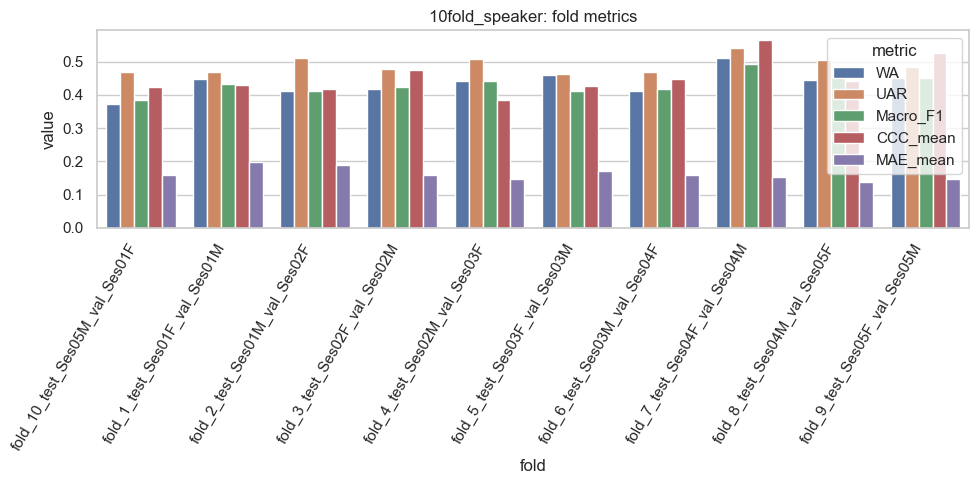

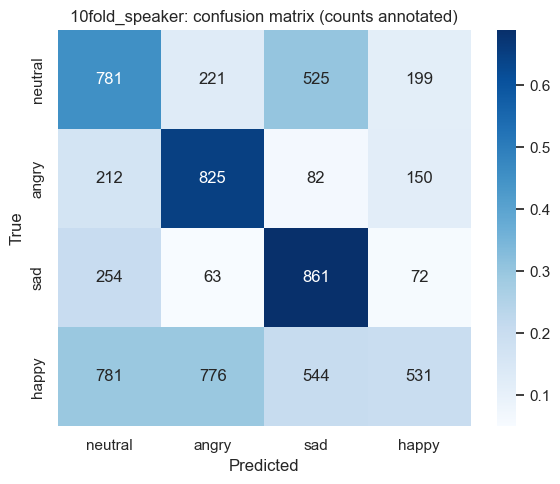

In [8]:
metric_cols = [
    "WA", "UAR", "Macro_F1", "Weighted_F1",
    "CCC_valence", "CCC_arousal", "CCC_dominance", "CCC_mean",
    "MAE_valence", "MAE_arousal", "MAE_dominance", "MAE_mean",
    "RMSE_valence", "RMSE_arousal", "RMSE_dominance", "RMSE_mean",
]
summary = metrics_df[metric_cols].agg(["mean", "std"]).T.reset_index()
summary.columns = ["metric", "mean", "std"]
summary.to_csv(REPORT_DIR / f"{PROTOCOL}_metrics_summary.csv", index=False, encoding="utf-8-sig")
display(summary)

plt.figure(figsize=(10, 5))
plot_df = metrics_df.melt(id_vars=["fold"], value_vars=["WA", "UAR", "Macro_F1", "CCC_mean", "MAE_mean"], var_name="metric", value_name="value")
sns.barplot(data=plot_df, x="fold", y="value", hue="metric")
plt.xticks(rotation=60, ha="right")
plt.title(f"{PROTOCOL}: fold metrics")
plt.tight_layout()
plt.savefig(FIGURE_DIR / f"{PROTOCOL}_fold_metrics.png", dpi=180)
plt.show()

y_true = all_predictions_df["emotion_id"].astype(int).values
y_pred = all_predictions_df["pred_emotion_id"].astype(int).values
cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2, 3])
cm_norm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_norm, annot=cm, fmt="d", cmap="Blues", xticklabels=EMOTIONS, yticklabels=EMOTIONS)
plt.title(f"{PROTOCOL}: confusion matrix (counts annotated)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig(FIGURE_DIR / f"{PROTOCOL}_confusion_matrix.png", dpi=180)
plt.show()

## 5. Final Report

Cell này lưu report Markdown để đọc nhanh bên ngoài notebook.

In [9]:
summary_lookup = {row.metric: (row["mean"], row["std"]) for _, row in summary.iterrows()}
def m(metric):
    mean, std = summary_lookup[metric]
    return f"{mean:.4f} ± {std:.4f}"

report_lines = [
    f"# {PROTOCOL} Multi-Task Model Report",
    "",
    "## Setting",
    "",
    "- Dataset: HF AbstractTTS/IEMOCAP local mirror.",
    "- Label setting: HF-major-emotion 4-class + AVD, N = 6,877.",
    f"- Split protocol: {PROTOCOL}.",
    f"- Feature mode: {FEATURE_MODE}.",
    f"- Input features: {', '.join(ACOUSTIC_METADATA_FEATURES)}.",
    "- Model: shared MLP encoder + emotion classification head + AVD regression head.",
    "- Future model slot: Emotion2Vec-guided acoustic cross-attention is defined in notebook, but requires full emotion2vec cache from notebook 02.",
    "",
    "## Mean ± std across folds",
    "",
    f"- WA: **{m('WA')}**",
    f"- UAR: **{m('UAR')}**",
    f"- Macro-F1: **{m('Macro_F1')}**",
    f"- Weighted-F1: **{m('Weighted_F1')}**",
    f"- CCC valence: **{m('CCC_valence')}**",
    f"- CCC arousal: **{m('CCC_arousal')}**",
    f"- CCC dominance: **{m('CCC_dominance')}**",
    f"- CCC mean: **{m('CCC_mean')}**",
    f"- MAE mean: **{m('MAE_mean')}**",
    f"- RMSE mean: **{m('RMSE_mean')}**",
    "",
    "## Files",
    "",
    f"- Metrics: `{REPORT_DIR / f'{PROTOCOL}_metrics.csv'}`",
    f"- Metrics summary: `{REPORT_DIR / f'{PROTOCOL}_metrics_summary.csv'}`",
    f"- Predictions: `{PREDICTION_DIR / f'{PROTOCOL}_all_predictions.csv'}`",
    f"- Models: `{MODEL_DIR}`",
    f"- Figures: `{FIGURE_DIR}`",
    "",
    "## Dataset upload needed",
    "",
    "For Kaggle, upload the folder `iemocap_multitask_train_data` as one Kaggle Dataset. The notebook will auto-detect it under `/kaggle/input/...`.",
    "",
    "Required inside the Kaggle Dataset folder:",
    "",
    "1. `metadata/iemocap_metadata_full.csv`",
    "2. `metadata/iemocap_4class_avd_metadata.csv`",
    f"3. `splits/{SPLIT_PATH.name}`",
    "4. `splits/*.json` if you want the fold definitions in nested JSON form.",
    "",
    "The current sanity baseline reads metadata/split tables only. Raw WAV files are still needed for feature extraction and final Emotion2Vec training:",
    "",
    "5. `audio_wav/` or the existing local `06_w2v_based_models/datasets/AbstractTTS_IEMOCAP/audio_wav/`.",
    "",
    "For the final Emotion2Vec-CoAttention model, also upload/cache:",
    "",
    "6. `features/iemocap_emotion2vec_tokens.npz` or an equivalent utterance/token embedding cache generated by notebook 02.",
    "7. `features/iemocap_acoustic_features.npz` if using handcrafted acoustic branch beyond metadata features.",
]

report_path = REPORT_DIR / f"{PROTOCOL}_model_report.md"
report_path.write_text("\n".join(report_lines), encoding="utf-8")
display(Markdown("\n".join(report_lines)))
print("Saved:", report_path)

# 10fold_speaker Multi-Task Model Report

## Setting

- Dataset: HF AbstractTTS/IEMOCAP local mirror.
- Label setting: HF-major-emotion 4-class + AVD, N = 6,877.
- Split protocol: 10fold_speaker.
- Feature mode: metadata_acoustic_baseline.
- Input features: duration, speaking_rate, pitch_mean, pitch_std, rms, relative_db.
- Model: shared MLP encoder + emotion classification head + AVD regression head.
- Future model slot: Emotion2Vec-guided acoustic cross-attention is defined in notebook, but requires full emotion2vec cache from notebook 02.

## Mean ± std across folds

- WA: **0.4371 ± 0.0368**
- UAR: **0.4889 ± 0.0260**
- Macro-F1: **0.4314 ± 0.0300**
- Weighted-F1: **0.4092 ± 0.0386**
- CCC valence: **0.2254 ± 0.0529**
- CCC arousal: **0.6370 ± 0.0544**
- CCC dominance: **0.5004 ± 0.0867**
- CCC mean: **0.4543 ± 0.0542**
- MAE mean: **0.1621 ± 0.0192**
- RMSE mean: **0.2045 ± 0.0249**

## Files

- Metrics: `D:\UTE\Speech Programming\Speech Project\06_w2v_based_models\04MultiTask Emotion2Vec CoAttention 10Fold\reports\10fold_speaker_metrics.csv`
- Metrics summary: `D:\UTE\Speech Programming\Speech Project\06_w2v_based_models\04MultiTask Emotion2Vec CoAttention 10Fold\reports\10fold_speaker_metrics_summary.csv`
- Predictions: `D:\UTE\Speech Programming\Speech Project\06_w2v_based_models\04MultiTask Emotion2Vec CoAttention 10Fold\predictions\10fold_speaker_all_predictions.csv`
- Models: `D:\UTE\Speech Programming\Speech Project\06_w2v_based_models\04MultiTask Emotion2Vec CoAttention 10Fold\models`
- Figures: `D:\UTE\Speech Programming\Speech Project\06_w2v_based_models\04MultiTask Emotion2Vec CoAttention 10Fold\figures`

## Dataset upload needed

For Kaggle, upload the folder `iemocap_multitask_train_data` as one Kaggle Dataset. The notebook will auto-detect it under `/kaggle/input/...`.

Required inside the Kaggle Dataset folder:

1. `metadata/iemocap_metadata_full.csv`
2. `metadata/iemocap_4class_avd_metadata.csv`
3. `splits/iemocap_10fold_speaker_long.csv`
4. `splits/*.json` if you want the fold definitions in nested JSON form.

The current sanity baseline reads metadata/split tables only. Raw WAV files are still needed for feature extraction and final Emotion2Vec training:

5. `audio_wav/` or the existing local `06_w2v_based_models/datasets/AbstractTTS_IEMOCAP/audio_wav/`.

For the final Emotion2Vec-CoAttention model, also upload/cache:

6. `features/iemocap_emotion2vec_tokens.npz` or an equivalent utterance/token embedding cache generated by notebook 02.
7. `features/iemocap_acoustic_features.npz` if using handcrafted acoustic branch beyond metadata features.

Saved: D:\UTE\Speech Programming\Speech Project\06_w2v_based_models\04MultiTask Emotion2Vec CoAttention 10Fold\reports\10fold_speaker_model_report.md
